## Rush 104
#### Cleaning and exploring data 

In [65]:
import pandas as pd

df=pd.read_csv('../data/rushroute_deliveries.csv')

df.head()

,delivery_id,distance_km,driver_active_orders,weather,pickup_hour,item_count,customer_tier,promised_minutes,delay_minutes,was_late
0,D101167,35.6,0,clear,14,4,standard,99,2,0
1,D101887,22.5,9,storm,13,2,standard,68,3,0
2,D100570,8.7,9,clear,13,7,standard,45,10,0
3,D100494,15.9,3,rain,4,5,standard,57,11,0
4,D101913,18.0,8,rain,20,8,standard,67,60,1


In [66]:
df.shape

(2030, 10)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   delivery_id           2030 non-null   object 
 1   distance_km           1989 non-null   float64
 2   driver_active_orders  2030 non-null   int64  
 3   weather               2015 non-null   object 
 4   pickup_hour           2030 non-null   int64  
 5   item_count            2030 non-null   int64  
 6   customer_tier         2030 non-null   object 
 7   promised_minutes      2030 non-null   int64  
 8   delay_minutes         2030 non-null   int64  
 9   was_late              2030 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 158.7+ KB


In [68]:
df.describe()

,distance_km,driver_active_orders,pickup_hour,item_count,promised_minutes,delay_minutes,was_late
count,1989.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000
mean,12.550226,4.937438,11.349754,4.532512,49.559606,13.542857,0.107882
std,6.994005,3.198621,7.007694,2.340143,15.673924,21.391465,0.310307
min,-17.200000,0.000000,0.000000,1.000000,21.000000,0.000000,0.000000
25%,7.500000,2.000000,5.000000,2.000000,38.000000,4.000000,0.000000
50%,11.200000,5.000000,11.000000,5.000000,46.000000,8.000000,0.000000
75%,16.100000,8.000000,17.000000,7.000000,57.750000,12.000000,0.000000
max,48.300000,10.000000,27.000000,8.000000,127.000000,120.000000,1.000000


In [69]:
df.isnull().sum()

delivery_id              0
distance_km             41
driver_active_orders     0
weather                 15
pickup_hour              0
item_count               0
customer_tier            0
promised_minutes         0
delay_minutes            0
was_late                 0
dtype: int64

According to the above output two columns of the dataset i.e. **distance_km** and **weather** have 41 and 15 NULL values respectively . 
Now , to ensure data integrity we will not remove these values but will replace them with a value 

**distance_km** holds an integer value so we can replace the null values with mean 

In [70]:
median_distance = df['distance_km'].median()

df.fillna({ 'distance_km': median_distance }, inplace=True)

df.isnull().sum()

delivery_id              0
distance_km              0
driver_active_orders     0
weather                 15
pickup_hour              0
item_count               0
customer_tier            0
promised_minutes         0
delay_minutes            0
was_late                 0
dtype: int64

**weather** column holds a categorical value so we cannot replace it with an interger value like mean but we can replace it with "unknown" or "missing"

In [71]:
df['weather'] = df['weather'].fillna('Unknown')
df.isnull().sum()


delivery_id             0
distance_km             0
driver_active_orders    0
weather                 0
pickup_hour             0
item_count              0
customer_tier           0
promised_minutes        0
delay_minutes           0
was_late                0
dtype: int64

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   delivery_id           2030 non-null   object 
 1   distance_km           2030 non-null   float64
 2   driver_active_orders  2030 non-null   int64  
 3   weather               2030 non-null   object 
 4   pickup_hour           2030 non-null   int64  
 5   item_count            2030 non-null   int64  
 6   customer_tier         2030 non-null   object 
 7   promised_minutes      2030 non-null   int64  
 8   delay_minutes         2030 non-null   int64  
 9   was_late              2030 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 158.7+ KB


## Looking for duplicate values 

In [73]:
df.duplicated().sum()

np.int64(30)

In [74]:
# Dropping duplicates
df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

## Checking for invalid values 

In [75]:
df.dtypes

delivery_id              object
distance_km             float64
driver_active_orders      int64
weather                  object
pickup_hour               int64
item_count                int64
customer_tier            object
promised_minutes          int64
delay_minutes             int64
was_late                  int64
dtype: object

In [76]:
df[df['distance_km']<0]

,delivery_id,distance_km,driver_active_orders,weather,pickup_hour,item_count,customer_tier,promised_minutes,delay_minutes,was_late
130,D101786,-12.5,5,clear,4,8,standard,54,3,0
265,D100082,-17.2,10,storm,21,5,standard,60,3,0
1603,D100936,-6.4,9,clear,8,2,standard,32,6,0
1988,D101478,-10.5,9,clear,2,1,premium,40,4,0


there are 4 datapoints having negative distance value which is impossible 
we are going to replace these values with median distance


In [77]:
median_distance = df.loc[df["distance_km"] >= 0, "distance_km"].median()

df.loc[df["distance_km"] < 0, "distance_km"] = median_distance

df[df['distance_km']<0]

,delivery_id,distance_km,driver_active_orders,weather,pickup_hour,item_count,customer_tier,promised_minutes,delay_minutes,was_late


In [78]:
(df["pickup_hour"] > 23).sum()
df[df["pickup_hour"]>23]



,delivery_id,distance_km,driver_active_orders,weather,pickup_hour,item_count,customer_tier,promised_minutes,delay_minutes,was_late
700,D100212,8.9,8,clear,26,4,standard,41,5,0
1094,D100075,11.7,10,clear,27,2,premium,44,8,0
1472,D100167,25.0,9,clear,27,4,standard,76,11,0
1482,D100443,10.8,7,clear,26,8,standard,51,5,0


In [79]:
df = df[(df["pickup_hour"] >= 0) & (df["pickup_hour"] <= 23)]

In [80]:
((df["pickup_hour"] < 0) | (df["pickup_hour"] > 23)).sum()

np.int64(0)

The dataset contained 4 records with pickup_hour values greater than 23. Since valid pickup hours must fall between 0 and 23, these records were considered invalid and removed. Because they represented a very small proportion of the dataset, removing them had negligible impact on the overall analysis while improving data quality.

In [81]:
(df["weather"].str.strip() == "").sum()

np.int64(0)

In [82]:
(df['item_count']<0).sum()

np.int64(0)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 0 to 2029
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   delivery_id           1996 non-null   object 
 1   distance_km           1996 non-null   float64
 2   driver_active_orders  1996 non-null   int64  
 3   weather               1996 non-null   object 
 4   pickup_hour           1996 non-null   int64  
 5   item_count            1996 non-null   int64  
 6   customer_tier         1996 non-null   object 
 7   promised_minutes      1996 non-null   int64  
 8   delay_minutes         1996 non-null   int64  
 9   was_late              1996 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 171.5+ KB


In [84]:
df["was_late"].value_counts()

was_late
0    1780
1     216
Name: count, dtype: int64

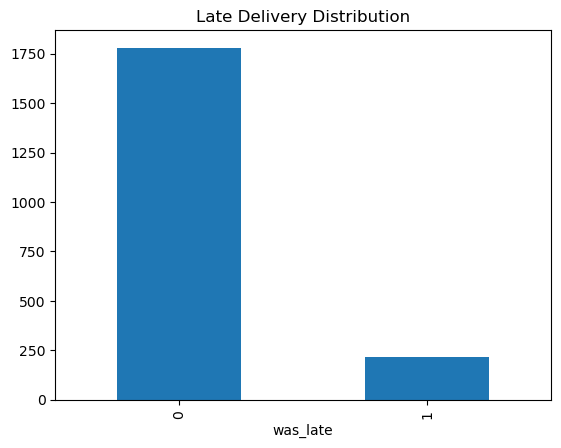

In [85]:
import matplotlib.pyplot as plt
df["was_late"].value_counts().plot(kind="bar")
plt.title("Late Delivery Distribution")
plt.show()

In [86]:
df["was_late"].value_counts(normalize=True) * 100

was_late
0    89.178357
1    10.821643
Name: proportion, dtype: float64

The dataset is highly imbalanced. Approximately 89% of deliveries were completed on time, while only 11% were late. This indicates that late deliveries are relatively uncommon.

Because the majority of deliveries are on time, accuracy alone is not an appropriate evaluation metric. For example, a model that predicts every delivery as "not late" would still achieve high accuracy but would fail to identify late deliveries. Therefore, metrics such as precision and recall will be more informative in RUSH-105.

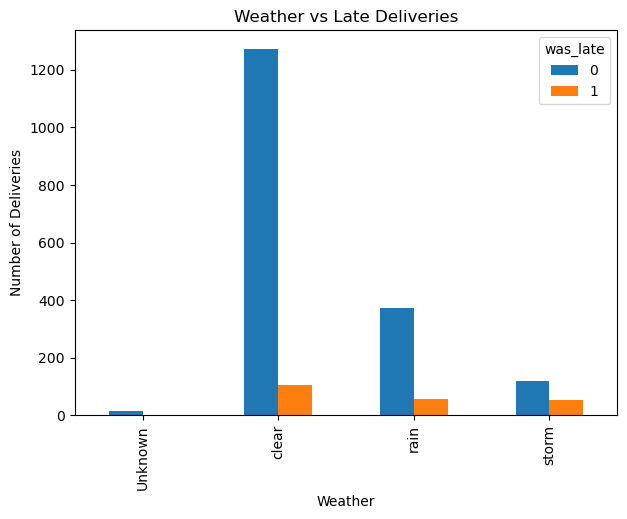

In [87]:
weather_late = pd.crosstab(df["weather"], df["was_late"])

weather_late.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Weather vs Late Deliveries")
plt.xlabel("Weather")
plt.ylabel("Number of Deliveries")

plt.show()

In [88]:
pd.crosstab(
    df["weather"],
    df["was_late"],
    normalize="index"
) * 100

was_late,0,1
weather,,
Unknown,93.333333,6.666667
clear,92.385787,7.614213
rain,86.946387,13.053613
storm,68.786127,31.213873


Storm conditions have the highest proportion of late deliveries (31.2%), which is more than four times higher than clear weather (7.6%). This indicates that severe weather is a significant operational risk and should be considered when estimating delivery risk.

<Figure size 600x400 with 0 Axes>

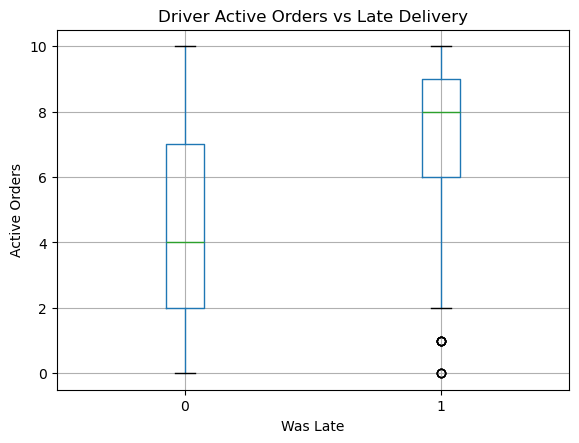

In [89]:
plt.figure(figsize=(6,4))

df.boxplot(column="driver_active_orders", by="was_late")

plt.title("Driver Active Orders vs Late Delivery")
plt.suptitle("")
plt.xlabel("Was Late")
plt.ylabel("Active Orders")

plt.show()

In [90]:
df.groupby("was_late")["driver_active_orders"].mean()

was_late
0    4.646629
1    7.347222
Name: driver_active_orders, dtype: float64

Late deliveries are associated with significantly higher driver workloads. On average, late deliveries occur when drivers are handling approximately 7.35 active orders compared to 4.65 for on-time deliveries. This suggests driver workload is an important predictor of delivery delays.

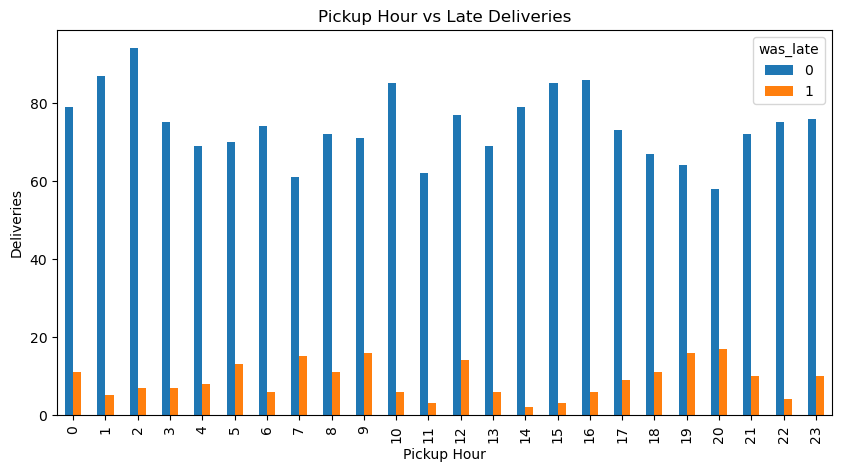

In [91]:
pickup = pd.crosstab(
    df["pickup_hour"],
    df["was_late"]
)

pickup.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Pickup Hour vs Late Deliveries")
plt.xlabel("Pickup Hour")
plt.ylabel("Deliveries")
plt.show()

In [92]:
pd.crosstab(
    df["pickup_hour"],
    df["was_late"],
    normalize="index"
) * 100

was_late,0,1
pickup_hour,,
0,87.777778,12.222222
1,94.565217,5.434783
2,93.069307,6.930693
3,91.463415,8.536585
4,89.610390,10.389610
5,84.337349,15.662651
6,92.500000,7.500000
7,80.263158,19.736842
8,86.746988,13.253012


Deliveries picked up during the evening (19:00–20:00) and morning rush hours (07:00–09:00) show noticeably higher late-delivery rates than most other hours. This suggests operational congestion during peak demand periods contributes to delivery delays.

<Figure size 600x400 with 0 Axes>

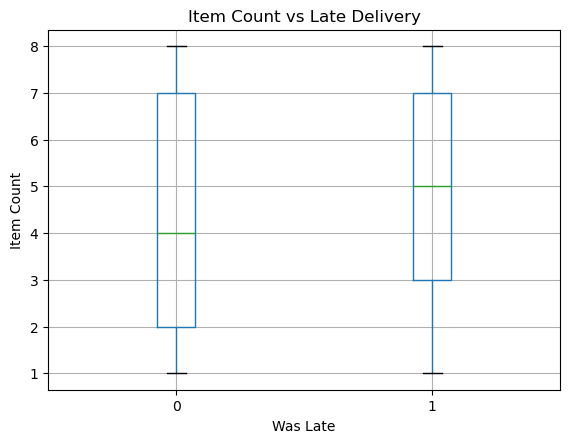

In [93]:
plt.figure(figsize=(6,4))

df.boxplot(column="item_count", by="was_late")

plt.title("Item Count vs Late Delivery")
plt.suptitle("")
plt.xlabel("Was Late")
plt.ylabel("Item Count")

plt.show()

In [94]:
df.groupby("was_late")["item_count"].mean()

was_late
0    4.497753
1    4.870370
Name: item_count, dtype: float64

Late deliveries contain slightly more items on average than on-time deliveries (4.87 vs 4.50). However, the difference is relatively small, suggesting that item count alone is not a strong predictor of delivery lateness.

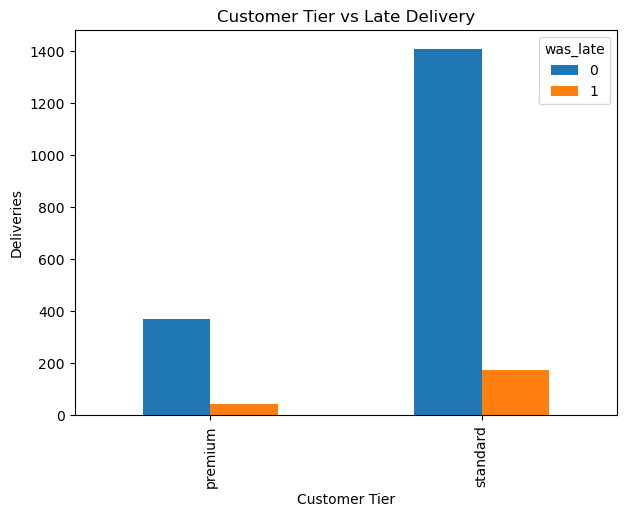

In [95]:
customer = pd.crosstab(
    df["customer_tier"],
    df["was_late"]
)

customer.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Customer Tier vs Late Delivery")
plt.xlabel("Customer Tier")
plt.ylabel("Deliveries")

plt.show()

In [96]:
pd.crosstab(
    df["customer_tier"],
    df["was_late"],
    normalize="index"
) * 100

was_late,0,1
customer_tier,,
premium,89.805825,10.194175
standard,89.015152,10.984848


The late-delivery rates for Premium and Standard customers are very similar (approximately 10–11%). This suggests customer tier has little influence on whether a delivery is late and is unlikely to be a strong predictive feature.

In [97]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,distance_km,driver_active_orders,pickup_hour,item_count,promised_minutes,delay_minutes,was_late
distance_km,1.000000,0.002958,-0.012458,0.012340,0.960745,0.132401,0.107097
driver_active_orders,0.002958,1.000000,-0.015478,-0.011372,0.005611,0.247129,0.261714
pickup_hour,-0.012458,-0.015478,1.000000,-0.004055,-0.010401,0.007303,0.022102
item_count,0.012340,-0.011372,-0.004055,1.000000,0.233980,0.034299,0.049443
promised_minutes,0.960745,0.005611,-0.010401,0.233980,1.000000,0.131984,0.112098
delay_minutes,0.132401,0.247129,0.007303,0.034299,0.131984,1.000000,0.881305
was_late,0.107097,0.261714,0.022102,0.049443,0.112098,0.881305,1.000000


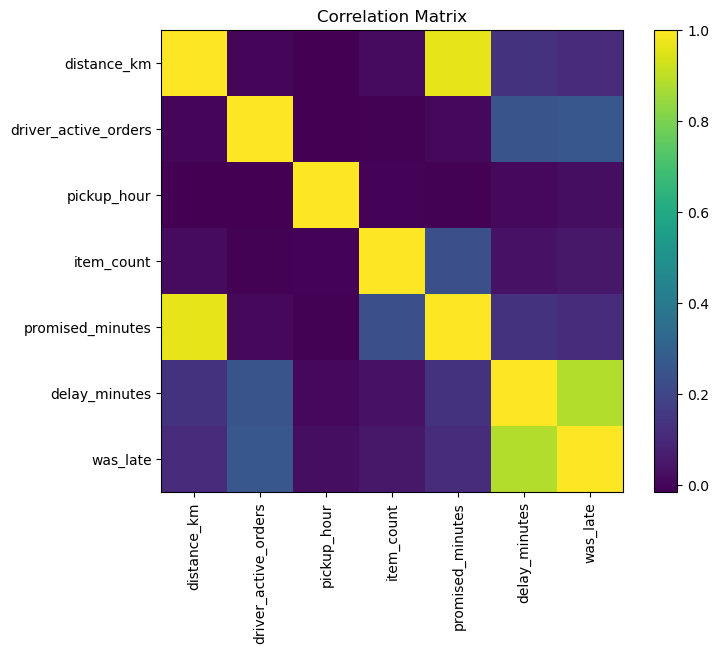

In [98]:
import matplotlib.pyplot as plt

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

The strongest correlation with was_late is delay_minutes (0.881), but this variable must be excluded from the predictive model because it is only known after the delivery has been completed, creating data leakage. Among the pre-delivery features, driver_active_orders shows the strongest relationship with lateness (0.262), while distance_km has a weaker positive relationship (0.107). pickup_hour and item_count exhibit only weak correlations.

## Training a classification model 

#### Feature Selection

In [102]:
features=[
    "distance_km",
    "driver_active_orders",
    "pickup_hour",
    "item_count",
    "promised_minutes",
    "weather",
    "customer_tier"

]

target= "was_late"

we excluded the delay_minutes column because this column has the values which are known after the delivery is done 
i.e. how many minutes the delivery was delay , that could be known only after delivery 
this can be data leakage if included in model , so we decided to remove the column from model features

In [104]:
x=df[features]
y=df[target]


## Encoding Categorical Features 

In [105]:
X = pd.get_dummies(
    x,
    columns=["weather", "customer_tier"],
    drop_first=True
)

In [107]:
X

,distance_km,driver_active_orders,pickup_hour,item_count,promised_minutes,weather_clear,weather_rain,weather_storm,customer_tier_standard
0,35.6,0,14,4,99,True,False,False,True
1,22.5,9,13,2,68,False,False,True,True
2,8.7,9,13,7,45,True,False,False,True
3,15.9,3,4,5,57,False,True,False,True
4,18.0,8,20,8,67,False,True,False,True
...,...,...,...,...,...,...,...,...,...
2025,10.0,3,22,1,38,False,True,False,True
2026,6.2,6,23,7,39,True,False,False,True
2027,11.8,3,2,7,51,True,False,False,False
2028,9.2,6,17,1,37,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Training a logistic regression model 

In [109]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [110]:
y_pred=model.predict(X_test)

In [111]:
y_prob = model.predict_proba(X_test)[:,1]

## Model Evaluation

In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy=accuracy_score(
    y_test,
    y_pred
)

precision=precision_score(
    y_test,
    y_pred
)

recall=recall_score(
    y_test,
    y_pred
)

f1=f1_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")

Accuracy : 0.89
Precision: 0.50
Recall   : 0.07
F1 Score : 0.12


In [116]:
confusion_matrix(
    y_test,
    y_pred
)

array([[354,   3],
       [ 40,   3]])

In [118]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       357
           1       0.50      0.07      0.12        43

    accuracy                           0.89       400
   macro avg       0.70      0.53      0.53       400
weighted avg       0.86      0.89      0.85       400



In [120]:
results = {
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
}

evaluation_df = pd.DataFrame(results)

round(evaluation_df,2)

,Metric,Value
0,Accuracy,0.89
1,Precision,0.50
2,Recall,0.07
3,F1 Score,0.12


The Logistic Regression model achieved an accuracy of 89%. However, because the dataset is imbalanced, accuracy alone is not sufficient to evaluate performance. The model's precision indicates how reliable its late-delivery predictions are, while recall measures how effectively it identifies actual late deliveries. The F1-score provides a balanced measure of both precision and recall.